In [88]:
import pandas as pd
import pickle
import time

with open('../../models/model_meal.pickle', 'rb') as f:
    model_meal = pickle.load(f)

with open('../../models/model_workout.pickle', 'rb') as f:
    model_workout = pickle.load(f)

with open('../../models/model_progress.pickle', 'rb') as f:
    model_progress = pickle.load(f)

In [89]:
# Cek untuk model Meal
meal_feat = model_meal['features']
print("Kolom untuk Meal:", meal_feat)

# Cek untuk model Workout
workout_feat = model_workout['features']
print("Kolom untuk Workout:", workout_feat)

# Cek untuk model Progress
progress_feat = model_progress['features']
print("Kolom untuk Progress:", progress_feat)

Kolom untuk Meal: ['Energy', 'Protein', 'Carbs']
Kolom untuk Workout: ['Goal_Encoded', 'Workout_Frequency_x', 'level_Encoded', 'Gender_Encoded', 'Age_x', 'Initial_Weight_kg_x', 'environment_Encoded', 'Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim']
Kolom untuk Progress: ['Age', 'Gender_Encoded', 'Height_cm', 'Initial_Weight_kg', 'BMI_Category_x_Encoded', 'Body_Fat_Category', 'Goal_Encoded', 'Workout_Frequency', 'Average_Duration_Minutes', 'level_Encoded', 'Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim', 'Week']


In [90]:
data_meal = pd.DataFrame([{
    "Carbs": 200,
    "Energy": 2200,
    "Protein": 150
}])

data_meal = data_meal[meal_feat]

data_workout = pd.DataFrame([{
    'Goal_Encoded': 1,
    'Workout_Frequency_x': 6,
    'level_Encoded': 1,
    'Gender_Encoded': 1,
    'Age_x': 25,
    'Initial_Weight_kg_x': 90,
    'environment_Encoded': 1,
    'Badminton': 0,
    'Football': 1,
    'Basketball': 0,
    'Volleyball': 0,
    'Swim': 1
}])

data_workout = data_workout[workout_feat]

data_progress = pd.DataFrame([{
    'Age': 25,
    'Gender_Encoded': 1,
    'Height_cm': 175,
    'Initial_Weight_kg': 60,
    'BMI_Category_x_Encoded': 2,
    'Body_Fat_Category': 2,
    'Goal_Encoded': 1,
    'Workout_Frequency': 4,
    'Average_Duration_Minutes': 60,
    'level_Encoded': 1,
    'Badminton': 0,
    'Football': 1,
    'Basketball': 0,
    'Volleyball': 0,
    'Swim': 0,
    'Week': 1
}])

data_progress = data_progress[progress_feat]

In [91]:
model_knn = model_meal['knn_model']
scaler = model_meal['scaler']

total_waktu = 0
for i in range(100):
    mulai = time.time()
    
    data_scaled = scaler.transform(data_meal)
    model_knn.kneighbors(data_scaled)
    
    selesai = time.time()
    total_waktu += (selesai - mulai)

# Hitung rata-rata dalam detik dulu
rata_meal_detik = total_waktu / 100

# Ubah ke milidetik (ms)
rata_meal_ms = rata_meal_detik * 1000

print(f"Rata-rata Waktu Inference Meal: {rata_meal_ms:.2f} ms")

Rata-rata Waktu Inference Meal: 0.82 ms


In [119]:
# Ambil komponen dari paket
model_knn_workout = model_workout['knn_model']
scaler_workout = model_workout['scaler']
weights_workout = model_workout['weights']
fitur_workout = model_workout['features']

total_waktu = 0
for i in range(100):
    mulai = time.time()
    
    # 1. Scaling
    input_scaled = scaler_workout.transform(data_workout)
    
    # 2. Perkalian Bobot (Weights)
    df_weighted = pd.DataFrame(input_scaled, columns=fitur_workout)
    for col, w in weights_workout.items():
        if col in df_weighted.columns:
            df_weighted[col] = df_weighted[col] * w
    
    # 3. Mencari tetangga terdekat
    model_knn_workout.kneighbors(df_weighted.values)
    
    selesai = time.time()
    total_waktu += (selesai - mulai)

# Hitung rata-rata dan ubah ke ms
rata_workout_ms = (total_waktu / 100) * 1000

print(f"Rata-rata Waktu Inference Workout: {rata_workout_ms:.2f} ms")

Rata-rata Waktu Inference Workout: 2.00 ms


In [96]:
import onnxruntime as ort
import numpy as np
import pickle
import time
import os

# 1. Load Encoders & Feature List
with open('../../models/progress_encoders.pickle', 'rb') as f:
    encoders_data = pickle.load(f)
    progress_encoders = encoders_data["encoders"]
    progress_features = encoders_data["features"]

# 2. Load Semua 9 Model ONNX
ONNX_DIR = "../../models/onnx"
onnx_sessions = {}
for file in os.listdir(ONNX_DIR):
    if file.endswith(".onnx"):
        name = file.replace(".onnx", "")
        path = os.path.join(ONNX_DIR, file)
        onnx_sessions[name] = ort.InferenceSession(path, providers=["CPUExecutionProvider"])

print(f"Berhasil memuat {len(onnx_sessions)} model ONNX.")

Berhasil memuat 9 model ONNX.


In [97]:
user_input = {
    "Age": 25, "Gender": "Male", "Height_cm": 175, "Initial_Weight_kg": 60,
    "Goal": "Muscle Gain", "Level": "Beginner", "Body_Fat_Category": 2,
    "Frequency": 4, "Duration": 60, "Badminton": 0, "Football": 1, 
    "Basketball": 0, "Volleyball": 0, "Swim": 0
}

def proses_ke_array(user_in, week, weight):
    # Encoding (Sesuai logika skrip kamu)
    g_code = progress_encoders["Gender"].transform([user_in["Gender"]])[0]
    goal_code = progress_encoders["Goal"].transform([user_in["Goal"]])[0]
    lvl_code = progress_encoders["level"].transform([user_in["Level"]])[0]
    
    # BMI sederhana (untuk BMI_Category_x_Encoded)
    bmi = weight / ((user_in["Height_cm"]/100)**2)
    cat_bmi = "Normal" # Simplifikasi untuk test
    bmi_code = progress_encoders["BMI_Category_x"].transform([cat_bmi])[0]

    # Susun Array (Harus 16-18 fitur sesuai urutan)
    input_values = [
        user_in["Age"], g_code, user_in["Height_cm"], weight, bmi_code,
        user_in["Body_Fat_Category"], goal_code, user_in["Frequency"],
        user_in["Duration"], lvl_code, user_in["Badminton"], user_in["Football"],
        user_in["Basketball"], user_in["Volleyball"], user_in["Swim"], week
    ]
    return np.array([input_values], dtype=np.float32)

# Siapkan input sekali saja
input_final = proses_ke_array(user_input, 1, 60.0)

In [98]:
total_waktu = 0

for i in range(100):
    mulai = time.time()
    
    # Jalankan ke-9 session ONNX (Sesuai logika skrip kamu)
    for name, sess in onnx_sessions.items():
        inp_name = sess.get_inputs()[0].name
        sess.run(None, {inp_name: input_final})
        
    selesai = time.time()
    total_waktu += (selesai - mulai)

rata_progress_ms = (total_waktu / 100) * 1000
print(f"Rata-rata Waktu Inference Progress (9 ONNX Models): {rata_progress_ms:.2f} ms")

Rata-rata Waktu Inference Progress (9 ONNX Models): 0.26 ms


Tabel Hasil Latency:
                    Model  Inference Time (ms)
0     Meal Recommendation                 0.82
1  Workout Recommendation                 2.00
2           User Progress                 0.26


<Axes: title={'center': 'Perbandingan Kecepatan Model (dalam ms)'}, xlabel='Model'>

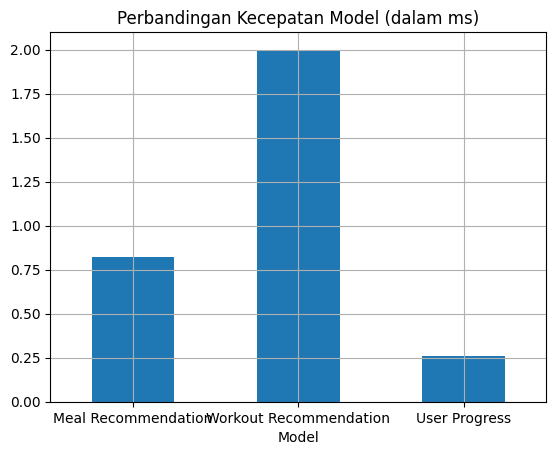

In [121]:
# 1. Kumpulkan semua hasil ke dalam satu dictionary
data_hasil = {
    'Model': ['Meal Recommendation', 'Workout Recommendation', 'User Progress'],
    'Inference Time (ms)': [rata_meal_ms, rata_workout_ms, rata_progress_ms]
}

# 2. Ubah menjadi DataFrame
df_grafik = pd.DataFrame(data_hasil)
df_grafik['Inference Time (ms)'] = df_grafik['Inference Time (ms)'].round(2)

# 3. Tampilkan tabelnya (untuk memastikan angka benar)
print("Tabel Hasil Latency:")
print(df_grafik)

# 4. Buat grafik batang (Bar Chart)
# Kita tambahkan rotasi 0 agar tulisan di bawah tidak miring
df_grafik.plot(
    kind='bar', 
    x='Model', 
    y='Inference Time (ms)', 
    title='Perbandingan Kecepatan Model (dalam ms)',
    legend=False,
    rot=0,
    grid=True
)